In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
COLOR_BLUE  = "#163767"
COLOR_RED   = "#E53935"
COLOR_GREEN = "#43A047"

df = pd.read_csv('../data/predictive_maintenance_v3.csv')

print(f"✅ Shape: {df.shape}")
print(f"\n📋 Colonnes: {list(df.columns)}")
df.head(10)

✅ Shape: (24042, 15)

📋 Colonnes: ['timestamp', 'machine_id', 'machine_type', 'vibration_rms', 'temperature_motor', 'current_phase_avg', 'pressure_level', 'rpm', 'operating_mode', 'hours_since_maintenance', 'ambient_temp', 'rul_hours', 'failure_within_24h', 'failure_type', 'estimated_repair_cost']


,timestamp,machine_id,machine_type,vibration_rms,temperature_motor,current_phase_avg,pressure_level,rpm,operating_mode,hours_since_maintenance,ambient_temp,rul_hours,failure_within_24h,failure_type,estimated_repair_cost
0,2024-01-01 00:00:00,1,CNC,0.81,49.51,5.10,23.6,860.9,idle,273.80,13.9,61.00,0,none,0
1,2024-01-01 00:03:00,1,CNC,0.75,40.58,5.30,23.6,899.6,idle,273.85,10.2,60.95,0,none,0
2,2024-01-01 00:21:00,1,CNC,0.71,49.70,NaN,21.3,862.7,idle,274.15,13.6,60.65,0,none,0
3,2024-01-01 00:45:00,1,CNC,0.76,43.04,4.79,22.6,870.4,idle,274.55,13.4,60.25,0,none,0
4,2024-01-01 00:54:00,1,CNC,0.88,41.39,4.44,22.2,881.9,idle,274.70,10.8,60.10,0,none,0
5,2024-01-01 01:23:00,1,CNC,0.94,42.00,4.77,23.6,853.2,idle,275.18,16.1,59.62,0,none,0
6,2024-01-01 01:47:00,1,CNC,0.88,41.71,4.10,25.7,917.6,idle,275.58,10.8,59.22,0,none,0
7,2024-01-01 01:55:00,1,CNC,2.93,54.57,10.13,78.0,2932.1,normal,275.72,11.4,59.08,0,none,0
8,2024-01-01 01:59:00,1,CNC,0.74,44.95,4.05,25.5,868.1,idle,275.78,11.6,59.02,0,none,0
9,2024-01-01 02:12:00,1,CNC,0.90,43.12,4.78,23.3,862.9,idle,276.00,16.1,58.80,0,none,0


In [3]:
# CELLULE 2 - Infos générales
print("=== TYPES ET VALEURS MANQUANTES ===")
print(df.dtypes)
print("\n=== VALEURS MANQUANTES ===")
print(df.isnull().sum())
print("\n=== STATISTIQUES DESCRIPTIVES ===")
df.describe()

=== TYPES ET VALEURS MANQUANTES ===
timestamp                   object
machine_id                   int64
machine_type                object
vibration_rms              float64
temperature_motor          float64
current_phase_avg          float64
pressure_level             float64
rpm                        float64
operating_mode              object
hours_since_maintenance    float64
ambient_temp               float64
rul_hours                  float64
failure_within_24h           int64
failure_type                object
estimated_repair_cost        int64
dtype: object

=== VALEURS MANQUANTES ===
timestamp                     0
machine_id                    0
machine_type                  0
vibration_rms              1000
temperature_motor           834
current_phase_avg           731
pressure_level              924
rpm                         533
operating_mode                0
hours_since_maintenance       0
ambient_temp                  0
rul_hours                     0
failure_withi

,machine_id,vibration_rms,temperature_motor,current_phase_avg,pressure_level,rpm,hours_since_maintenance,ambient_temp,rul_hours,failure_within_24h,estimated_repair_cost
count,24042.000000,23042.000000,23208.000000,23311.000000,23118.000000,23509.000000,24042.000000,24042.000000,24042.000000,24042.000000,24042.000000
mean,10.505033,1.623667,51.404295,8.823829,59.012233,1144.849317,172.630624,12.996398,27.812510,0.148074,608.870144
std,5.746455,1.081061,12.519279,5.366391,38.723271,912.670971,150.722469,2.883994,26.393801,0.355181,1566.793887
min,1.000000,0.350000,28.000000,2.200000,10.100000,124.100000,0.000000,8.000000,0.500000,0.000000,0.000000
25%,6.000000,0.820000,42.610000,4.630000,22.700000,489.400000,42.870000,10.500000,0.500000,0.000000,0.000000
50%,10.000000,1.270000,50.060000,6.430000,46.300000,856.000000,121.610000,13.000000,22.570000,0.000000,0.000000
75%,15.000000,2.270000,59.962500,13.120000,94.700000,1676.000000,295.575000,15.500000,46.410000,0.000000,0.000000
max,20.000000,10.000000,95.000000,35.000000,206.500000,4098.800000,575.630000,18.000000,98.340000,1.000000,7995.000000


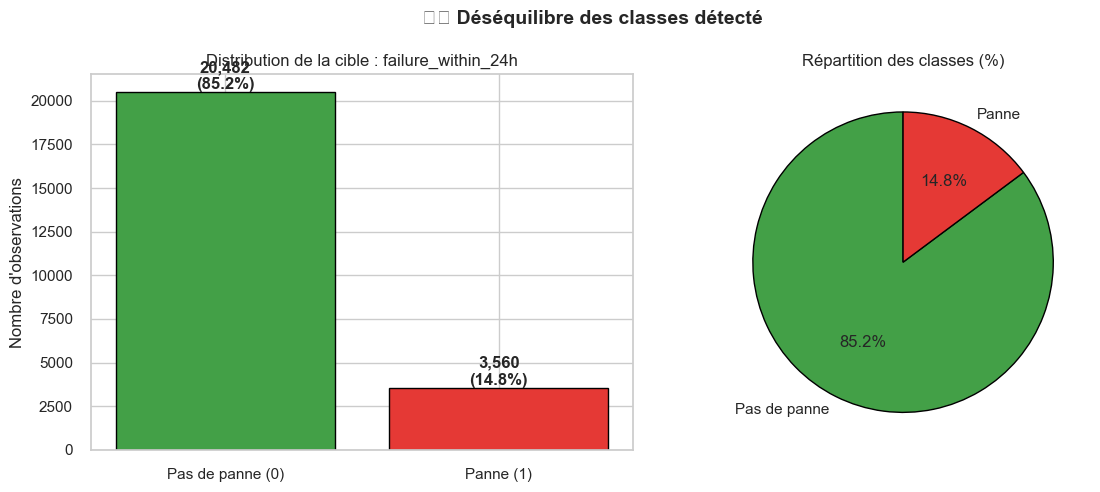

Ratio déséquilibre : 5.8:1 (majoritaire:minoritaire)


In [4]:
# CELLULE 3 - Distribution de la cible (déséquilibre des classes)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Graphique 1 - Comptage
counts = df['failure_within_24h'].value_counts().sort_index()
bars = axes[0].bar(['Pas de panne (0)', 'Panne (1)'], counts.values,
                   color=[COLOR_GREEN, COLOR_RED], edgecolor='black')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val,
                 f'{val:,}\n({val/len(df):.1%})',
                 ha='center', va='bottom', fontweight='bold')
axes[0].set_title('Distribution de la cible : failure_within_24h')
axes[0].set_ylabel("Nombre d'observations")

# Graphique 2 - Pie chart
axes[1].pie(counts.values, labels=['Pas de panne', 'Panne'],
            colors=[COLOR_GREEN, COLOR_RED],
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'black'})
axes[1].set_title('Répartition des classes (%)')

plt.suptitle('⚠️ Déséquilibre des classes détecté', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/eda_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

ratio = counts[0] / counts[1]
print(f"Ratio déséquilibre : {ratio:.1f}:1 (majoritaire:minoritaire)")

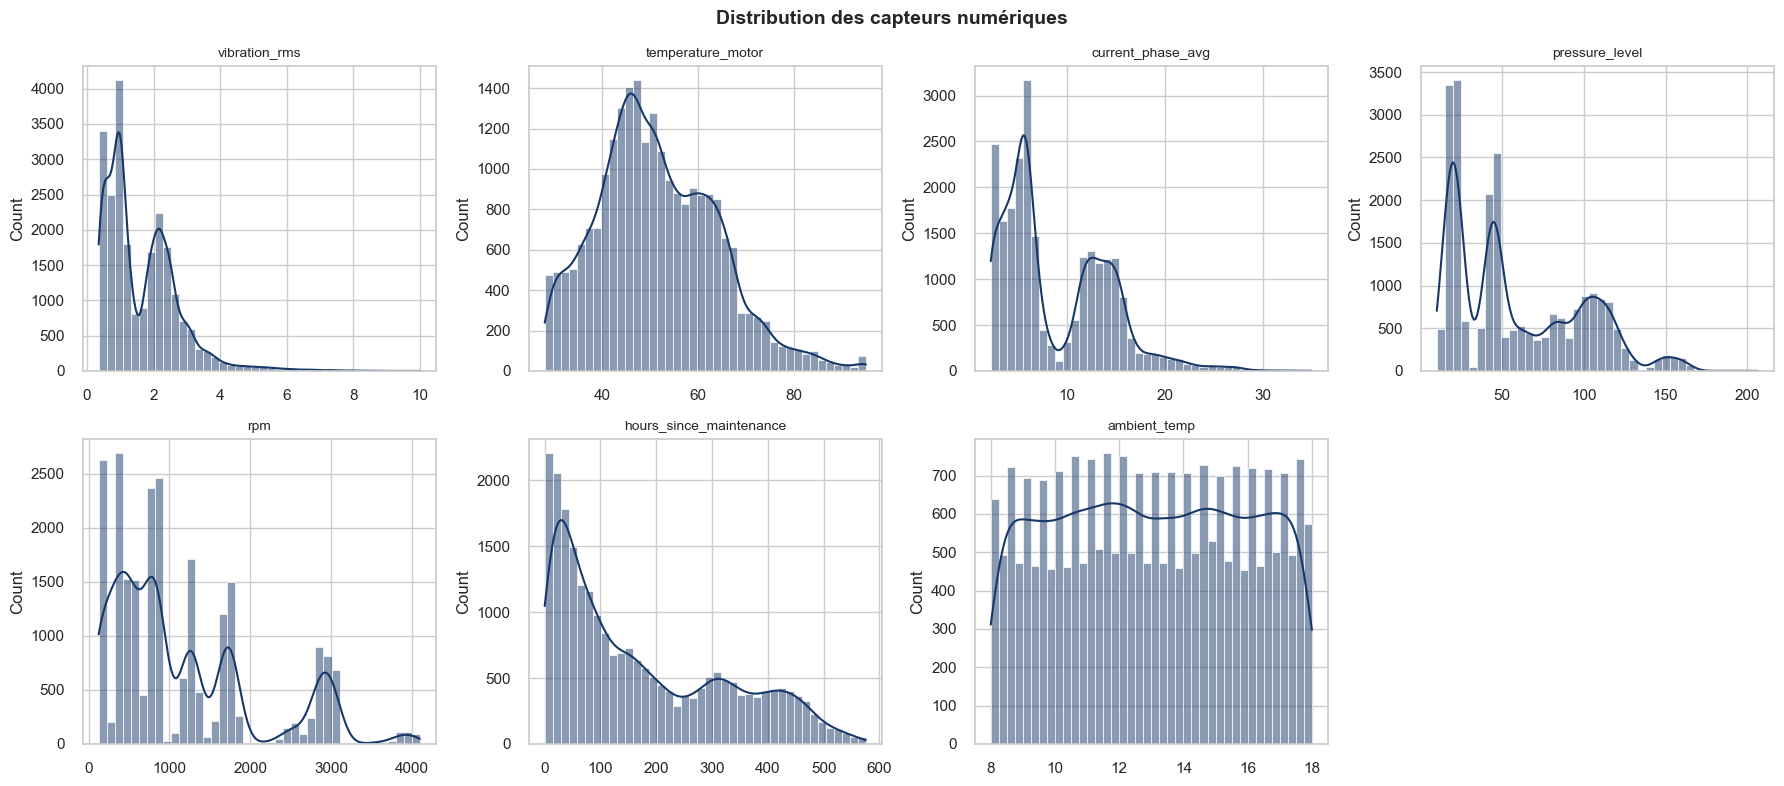

In [5]:
# CELLULE 4 - Distribution des capteurs numériques
NUMERIC_FEATURES = ['vibration_rms', 'temperature_motor', 'current_phase_avg',
                    'pressure_level', 'rpm', 'hours_since_maintenance', 'ambient_temp']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, feature in enumerate(NUMERIC_FEATURES):
    sns.histplot(df[feature].dropna(), kde=True, ax=axes[i], 
                 color=COLOR_BLUE, bins=40)
    axes[i].set_title(feature, fontsize=10)
    axes[i].set_xlabel('')

axes[-1].set_visible(False)

plt.suptitle('Distribution des capteurs numériques', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/eda_sensor_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

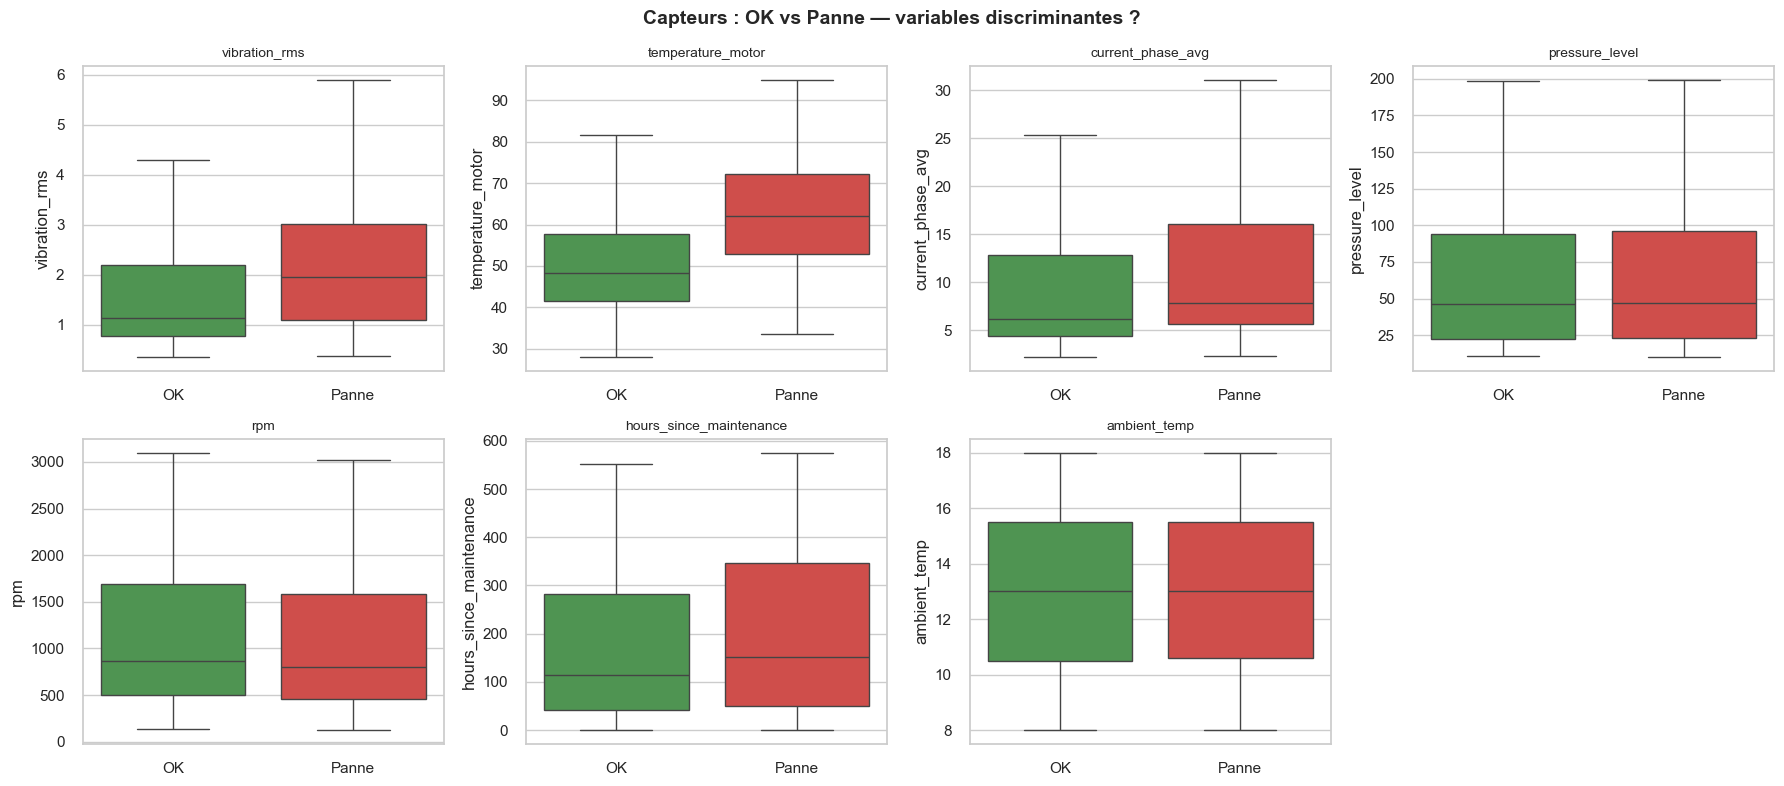

In [6]:
# CELLULE 5 - Boxplots capteurs par classe (panne vs pas panne)
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, feature in enumerate(NUMERIC_FEATURES):
    sns.boxplot(data=df, x='failure_within_24h', y=feature,
                hue='failure_within_24h',
                palette={0: COLOR_GREEN, 1: COLOR_RED},
                ax=axes[i], showfliers=False, legend=False)
    axes[i].set_title(feature, fontsize=10)
    axes[i].set_xlabel('')
    axes[i].set_xticklabels(['OK', 'Panne'])

axes[-1].set_visible(False)

plt.suptitle('Capteurs : OK vs Panne — variables discriminantes ?',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/eda_boxplots_by_class.png', dpi=150, bbox_inches='tight')
plt.show()

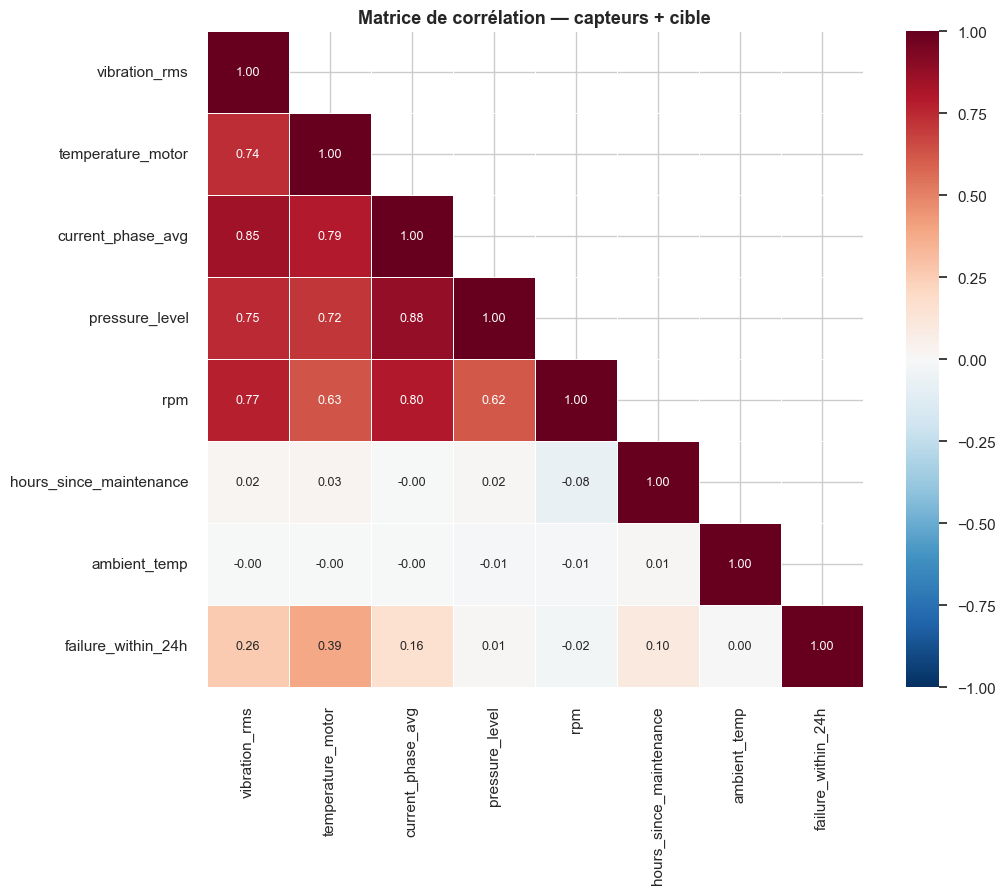

In [7]:
# CELLULE 6 - Heatmap de corrélation
fig, ax = plt.subplots(figsize=(11, 9))

cols = NUMERIC_FEATURES + ['failure_within_24h']
corr = df[cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5,
            annot_kws={'size': 9}, ax=ax)

ax.set_title('Matrice de corrélation — capteurs + cible',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/eda_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

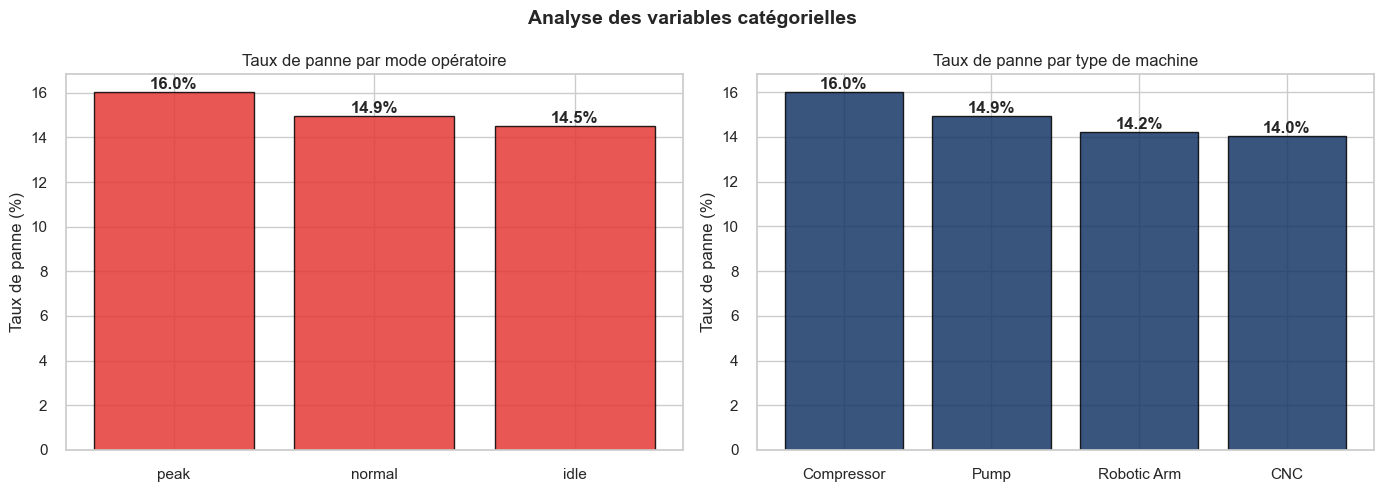

In [8]:
# CELLULE 7 - Taux de panne par mode opératoire et type de machine
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Taux de panne par operating_mode
failure_by_mode = df.groupby('operating_mode')['failure_within_24h'].mean().sort_values(ascending=False)
bars1 = axes[0].bar(failure_by_mode.index, failure_by_mode.values * 100,
                    color=COLOR_RED, edgecolor='black', alpha=0.85)
for bar, val in zip(bars1, failure_by_mode.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val*100,
                 f'{val*100:.1f}%', ha='center', va='bottom', fontweight='bold')
axes[0].set_title('Taux de panne par mode opératoire')
axes[0].set_ylabel('Taux de panne (%)')

# Taux de panne par machine_type
failure_by_type = df.groupby('machine_type')['failure_within_24h'].mean().sort_values(ascending=False)
bars2 = axes[1].bar(failure_by_type.index, failure_by_type.values * 100,
                    color=COLOR_BLUE, edgecolor='black', alpha=0.85)
for bar, val in zip(bars2, failure_by_type.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val*100,
                 f'{val*100:.1f}%', ha='center', va='bottom', fontweight='bold')
axes[1].set_title('Taux de panne par type de machine')
axes[1].set_ylabel('Taux de panne (%)')

plt.suptitle('Analyse des variables catégorielles', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/eda_categorical_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

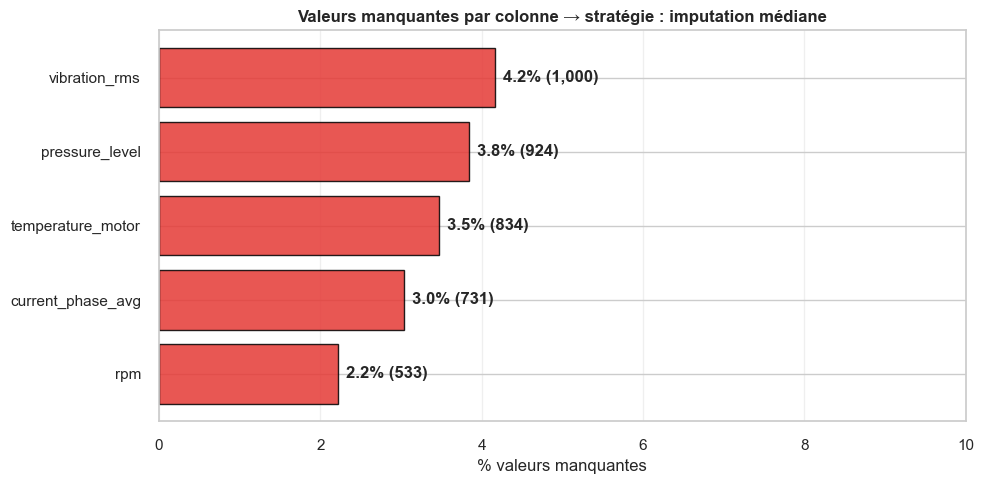


RÉSUMÉ EDA
Dataset : 24,042 lignes x 15 colonnes
Cible : failure_within_24h
Classe 0 (pas de panne) : 20,482 (85.2%)
Classe 1 (panne)        : 3,560 (14.8%)
Ratio déséquilibre      : 5.8:1
Valeurs manquantes      : 4,022 cellules
Variables les + corrélées à la cible : temperature_motor (0.39), vibration_rms (0.26)
Stratégie NaN           : imputation médiane
Stratégie déséquilibre  : SMOTE + class_weight + seuil optimisé


In [9]:
# CELLULE 8 - Valeurs manquantes + résumé EDA
fig, ax = plt.subplots(figsize=(10, 5))

missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=True)
missing_pct = (missing / len(df) * 100).round(2)

bars = ax.barh(missing.index, missing_pct.values,
               color=COLOR_RED, edgecolor='black', alpha=0.85)
for bar, pct, count in zip(bars, missing_pct.values, missing.values):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f'{pct:.1f}% ({count:,})', va='center', fontweight='bold')

ax.set_xlabel('% valeurs manquantes')
ax.set_title('Valeurs manquantes par colonne → stratégie : imputation médiane',
             fontsize=12, fontweight='bold')
ax.set_xlim(0, 10)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/eda_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*50)
print("RÉSUMÉ EDA")
print("="*50)
print(f"Dataset : {df.shape[0]:,} lignes x {df.shape[1]} colonnes")
print(f"Cible : failure_within_24h")
print(f"Classe 0 (pas de panne) : {(df['failure_within_24h']==0).sum():,} ({(df['failure_within_24h']==0).mean():.1%})")
print(f"Classe 1 (panne)        : {(df['failure_within_24h']==1).sum():,} ({(df['failure_within_24h']==1).mean():.1%})")
print(f"Ratio déséquilibre      : 5.8:1")
print(f"Valeurs manquantes      : {df.isnull().sum().sum():,} cellules")
print(f"Variables les + corrélées à la cible : temperature_motor (0.39), vibration_rms (0.26)")
print(f"Stratégie NaN           : imputation médiane")
print(f"Stratégie déséquilibre  : SMOTE + class_weight + seuil optimisé")